<a href="https://colab.research.google.com/github/Rumbie-Manhenda/ML-Zoomcamp/blob/main/Supervised_Learning_Notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What is AI?- Simulation of Human Intelligene by AI wihtout being explicitly programmed.

## How Machines Learn?

- Supervised learning- labeled data (X--> Y) Regression and Classification problems. This type of  ML works when you have labelled data
- Unsupervised Data , used unlablled data, it group and interprete data only based on the input data. Finds pattern in the inputted data and groups or classifies them e.g Clustering
- Reinforecement Learning, Learn through experience- trial and error, dodes not reply n a defined dataset with positive and negative reinforcements e.g robotics, games like alphaGo, chess etc

BIG DATA + INFRASTRUCTURE (Cloud) + COMPUTING POWER

Sofyware develpment Lifecycle ( SDLC) - process SWE follow to produce highest quality sofware in the shortes mount of time with Agile being a popular method used.

### ML also has its own SDLC with the below stages:
1. **Problem formation and undestanding** (Where can ML add value- is it an ethical solution to the problem, define inputs and outputs, what predictio errors rates will you except)
2. **Data collection and preparation-** find the needed data, annotate and wrangle the data e.g label the data, clean it remove irrelevamt features, feature engineering
3. **Model training and testing** - train data into treaining, testing and validated, slecte a ML algorithm, iterate and experiment while fine tuning
4. **Model deployment and testing** - evaluate model performance, fine-tuning the model and retrain , mantaine the model and monitorin overall perfomance.

### When Do we Use ML:
1. Predict outcome
2. Uncover trend and patterns in data
3. Have rules and steps that can not be coded
4. When your datset is too large to process by a human

#### Framing your problem:
Define the questions for your model
Define the required inputs and expected outputs

Transfer learning allows you to add your data on top of a pre-trained model, allowing you to traina  new model that inherits the learning of the previous model- reusability na efficiency. Ypu can find these on modelzoo.co or AWS mrketplace and Huggingface



In [ ]:
import pandas as pd

df = pd.read_csv('sample_data/california_housing_train.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
df.shape


(17000, 9)

Text(0.5, 0, 'Housing prices for Carlifonia - Y variable')

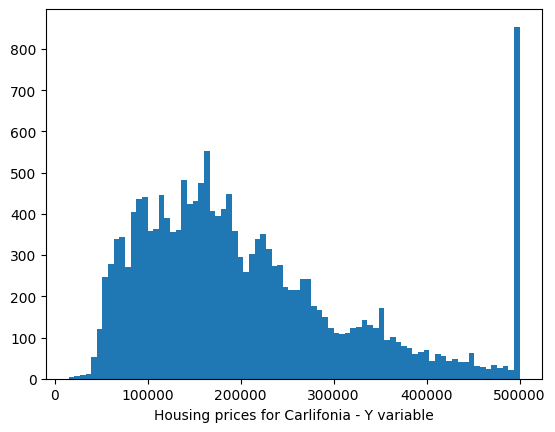

In [ ]:
#longitute is how far west a house is, while latitue how far  North a house is

import seaborn as sns
import matplotlib.pyplot as plt

plt.hist(df['median_house_value'], bins= 80)
plt.xlabel("Housing prices for Carlifonia - Y variable")


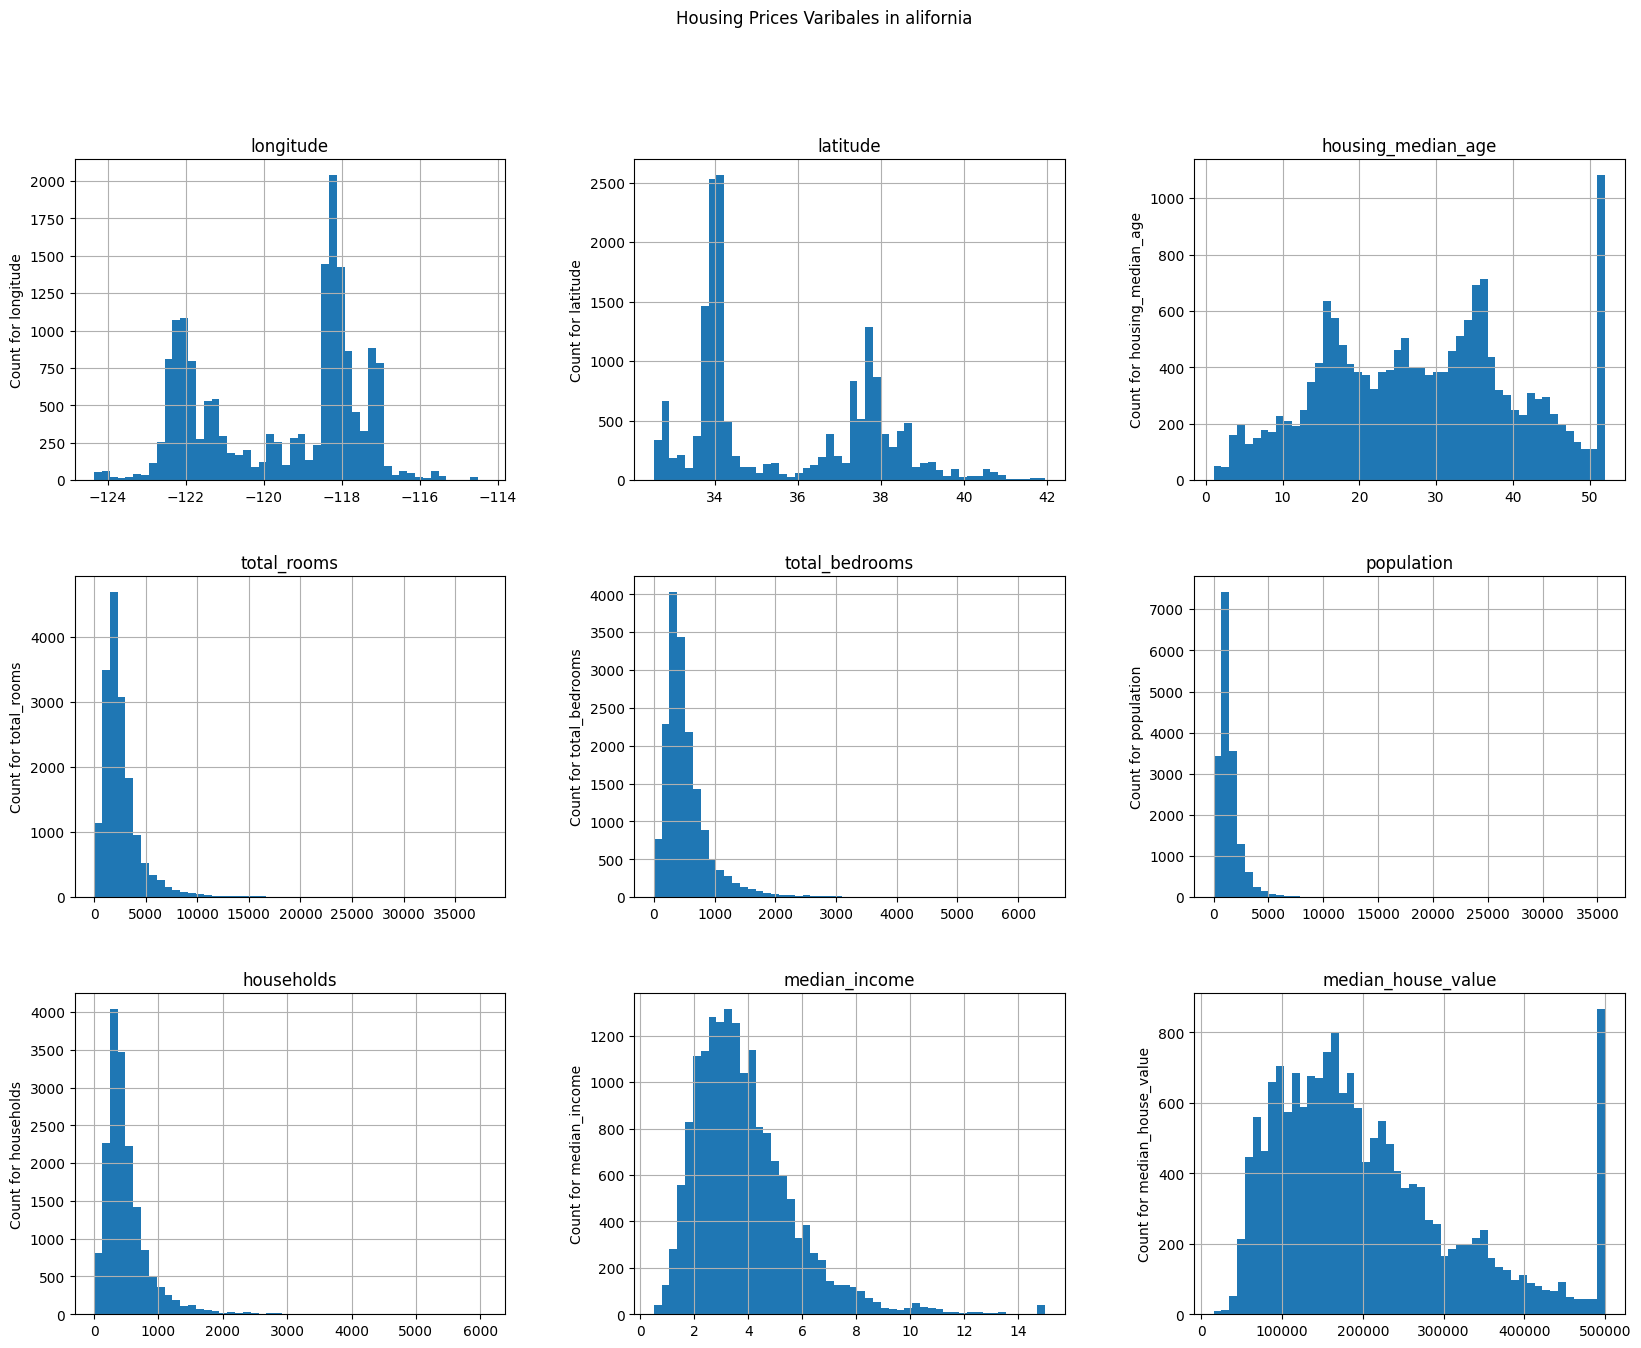

In [ ]:
df.hist(bins=50, figsize=(20,15))
plt.suptitle("Housing Prices Varibales in alifornia")
for i, ax in enumerate(plt.gcf().axes):
  ax.set_ylabel(f"Count for {df.columns[i]}")
plt.show()

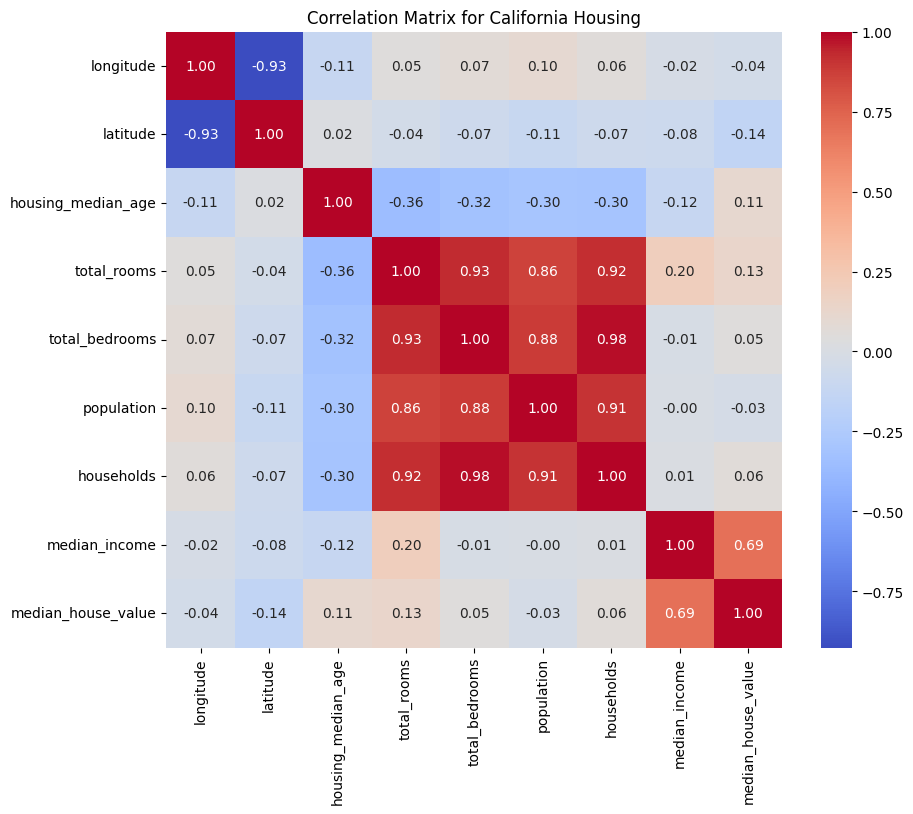

In [ ]:
##Correlation matrix
#Features with high correlation teaches the model the same thing.
corr_matrix = df.corr(numeric_only = True)
plt.figure(figsize= (10,8))
sns.heatmap(corr_matrix,
            annot= True,
            cmap= "coolwarm",
            fmt= ".2f",
            square= True)
plt.title("Correlation Matrix for California Housing")
plt.show()

In [ ]:

#CORRELATED FEATURES-
#1. latitutude, longitute
#2. total_rooms, households, total_bedrooms, population

In [ ]:
df["rooms_per_household"] = df['total_rooms']/df['households']
df["coords"] = df["latitude"]/ df["longitude"]
df["bedrooms_per_room"] = df["total_bedrooms"]/df["total_rooms"]
df["population_per_household"] = df["population"]/ df["households"]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 17000 non-null  float64
 1   latitude                  17000 non-null  float64
 2   housing_median_age        17000 non-null  float64
 3   total_rooms               17000 non-null  float64
 4   total_bedrooms            17000 non-null  float64
 5   population                17000 non-null  float64
 6   households                17000 non-null  float64
 7   median_income             17000 non-null  float64
 8   median_house_value        17000 non-null  float64
 9   rooms_per_household       17000 non-null  float64
 10  coords                    17000 non-null  float64
 11  bedrooms_per_room         17000 non-null  float64
 12  population_per_household  17000 non-null  float64
dtypes: float64(13)
memory usage: 1.7 MB


In [ ]:
#One hot encoding usually leads to high cardinaliyy menaing increased features which can result in the curse of dimensionality
#As number of featues increase it makes a model hard to learn and generalise and can increase training costs
#df.ocean_proximity.unique()
#df.ocean_proximity.value_counts()
##Encode categorical data to numeric using one hot encoding
#pd.get_dummies(data= df , clumns = ['ocean_proximity']])

df= df.drop(columns= ['total_rooms', 'households','total_bedrooms', 'population', 'longitude', 'latitude'], axis = 1)


In [ ]:
#Handling missing Data - Use KNN to impte missing values in small datasets. It identifies a sample with one or more missing values ,
#then it identifies the most similar samples that are complete and replace missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   housing_median_age        17000 non-null  float64
 1   median_income             17000 non-null  float64
 2   median_house_value        17000 non-null  float64
 3   rooms_per_household       17000 non-null  float64
 4   coords                    17000 non-null  float64
 5   bedrooms_per_room         17000 non-null  float64
 6   population_per_household  17000 non-null  float64
dtypes: float64(7)
memory usage: 929.8 KB


In [ ]:
from sklearn.impute import KNNImputer

#temp copy of dataset
df_tmp= df.copy()

columns_list = [col for col in df_tmp.columns if df_tmp[col].dtype != 'object']
new_column_list = [col for col in df_tmp.loc[:,df_tmp.isnull().any()]]
print(new_column_list)
df_tmp= df_tmp[new_column_list]
df_tmp.info()

SyntaxError: 'in' expected after for-loop variables (1700274779.py, line 7)

In [ ]:
knn= KNNImputer(n_neighbors=3)
knn.fit(df_tmp)

#transfom the data using the model,applied the tranformation to data

array_values = knn.transform(df_tmp)

hdf_tmp= pd.Dataframe(array_values, columns= new_column_list)
df_tmp.isnull().sum()

ValueError: at least one array or dtype is required

 ML is a branch of Computer Science and applied maths which uses mathematics and statistics to extract pattern- aprocess of extracting patterns from data using probablibilities to make the predictions form data.
 The goal of supervised ML is to come up with this function g such that when we apply X to it, the output is as close possible to the target variable. The process of finding g is training.

 Types of Supervised ML
 1. Classification - Bnary and Multiclass
 2. Regression
 3. Ranking - Mainly used in recommendation systems, here g scores every itsm with the probablity that you wil like it or not from 0-1 then sorts these items and show syou the top results.

### CRISP-DM Methodology - Cross-Industry Standard Process for Data Mining
 Its a methodology which decsribes how machine learning projects should be organized.
![CRISP-DM process](https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/01-intro/images/04-crisp-dm-02-process-diagram-imagegen-pilot.jpg)

1. Business understanding- The first goal is to identify the problem we want to solve,then decide if we actually need ML to solve this problem
2. Step 2 is Data understanding, here we visualize and analyze the data we have if its the right data and if we have right amaount of data.
3. Aftwerwards we start Data preparation which involves extracting features, cleaning the data and emoving noise, building data pipelines (A sequence of steps thta tales the raw data, applies transformaions and produces clean data), then we convert the data into tabular format, something we can put into a ML model.
4. Modeling: Train different models and choose the best one. Considering the results of this step, it is proper to decide if it is required to add new features or fix data issues.
5. Evaluation: Measure how well the model is performing and if it solves the business problem.
6. Deployment: Roll out to production to all the users. The evaluation and deployment often happen together - online evaluation.

### MODEL SELECTION

We need the validation set in addition toholding out the test set to avoid the multiple comparions problem.

**Multiple comparisons problem** (MCP): just by chance one model can be lucky and obtain good predictions because all of them are probabilistic.

The test set can help to avoid the MCP. Obtaining the best model is done with the training and validation datasets, while the test dataset is used for assuring that the proposed best model is the best.

This is the model selection process, and being able to set it up is one of the most important skills in machine learning. As a recipe:

1. Split the dataset into train, validation and test.
2. Train a model on the training set.
3. Evaluate it on the validation set.
4. Repeat steps 2-3 for as many models as you need.
5. Select the best model.
6. Apply the best model to the test set and make sure the performance is close to what you saw on validation.

After choosing the best model, we can then take the parameter of the best model, and retrain it from scratch with training data+validation data and then test it with tst data so validation data is not wasted.

### NUMPY


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

np.full(70,5)

np.arange(3,5)
np.linspace(0,100,9)
a= np.round(np.random.rand(4,2)*10, 2)
b= np.array([[0,1,0,1], [6,9,0,1]])


In [ ]:
def vector_to_vector(u,v):
  try:
    assert v.shape[0] == u.shape[0]
    results = 0.0
    for i in range(v.shape[0]):
      results = results + (u[i]*v[i])
    print(results)
  except:
    print("Ooops Assertion error")

vector_to_vector(a,b)
np.dot(a, b)


Ooops Assertion error


array([[10.44, 24.19,  0.  , 10.27],
       [47.88, 75.44,  0.  , 11.6 ],
       [27.96, 49.61,  0.  , 12.33],
       [50.7 , 76.78,  0.  ,  9.18]])

# Arrays, Vectors and Matrices in Machine Learning

## Topic: NumPy fundamentals • Data representation • Memory efficiency

#### 1. What is an array?

An array is a data structure used to store multiple values in an organised way. In NumPy, arrays are particularly useful for numerical computations because they allow us to perform mathematical operations on entire collections of numbers efficiently.

In machine learning, data is often represented as arrays because models need numerical inputs to perform calculations.

**For example:**
```
import numpy as np

numbers = np.array([1, 2, 3])
```

Here, numbers is a NumPy array containing three elements.

Why do we need arrays in ML?

Imagine a dataset containing information about 1,000 houses. Instead of working with each house individually, we can store their numerical features in arrays and perform calculations on all 1,000 houses at once.

Arrays help us organise data, perform vectorised operations and supply numerical inputs to machine learning algorithms.

2. What is a vector?

A vector is a one-dimensional array of numbers. It represents an ordered sequence of values.

v = np.array([1, 2, 3])

This vector has three elements:

v=[1,2,3]

Its shape is:

v.shape
# (3,)

The shape (3,) means that the array has one axis containing three elements. It is not the same shape as a two-dimensional array with three rows or three columns.

Example in machine learning: representing a house

Suppose we describe one house using three features:

- Size: 100 square metres

- Bedrooms: 3

- Age: 10 years

We can represent this house as a vector:

house = np.array([100, 3, 10])

Each element represents one feature of the same house.

Why is this useful you might ask? Well for starters, a machine learning model can use the values in this vector to make a prediction, such as estimating the house's price.

A vector can also represent model parameters, predictions or mathematical quantities used during training.

3. What is a matrix?

A matrix is a two-dimensional rectangular arrangement of numbers, organised into rows and columns.

For example:

A = np.array([
    [1, 2, 3],
    [7, 9, 0]
])

This creates the matrix:
```
A=[ 1   7
	2   9
    3   0
  ]
```
Its shape is:

A.shape
### (2, 3)

This means the matrix has 2 rows and 3 columns.

A matrix can also be understood as a collection of row vectors (or column vectors, depending on how the data is arranged). Matrices are also used to represent linear transformations, but these are related concepts rather than the same definition.

Example in machine learning: representing multiple houses

Suppose each row represents one house and each column represents a feature.

```
houses = np.array([
    [100, 3, 10],
    [150, 4, 5],
    [80,  2, 20]
])
````

The matrix has shape (3, 3) because it contains three houses and three features.

Why is this useful?

Instead of processing each house separately, a model can use the entire matrix to calculate predictions for multiple houses in one operation.

This is one of the foundations of numerical machine learning.

4. How are vectors, matrices and arrays related?

The word array is the general term for the NumPy data structure. A vector and a matrix describe arrays with particular numbers of dimensions.

1D

Vector

np.array([1, 2, 3])

One axis; shape (3,).

2D

Matrix

np.array([[1, 2], [3, 4]])

Two axes; shape (2, 2).

3D+

Multidimensional array (tensor)

np.zeros((2, 3, 4))

Three axes; shape (2, 3, 4). Commonly useful for batches of images, sequences and other complex data.

A useful distinction: in NumPy, a vector is usually a one-dimensional array, not necessarily a row or column matrix. For example, (3,), (1, 3) and (3, 1) are three different shapes.

5. Python lists vs. NumPy arrays: what is the difference?

This is one of the most important concepts to understand when learning NumPy.

Python lists

Consider this list:

numbers = [1, 2, 3, 4]

A Python list stores references to Python objects rather than storing all the numerical values directly in one compact numerical buffer.

Each integer is a Python object, and the list holds references to those objects. The objects and references involve additional memory overhead.

This flexibility is useful because a list can contain different data types:

mixed = [1, 2.5, True, "Banana"]

Python must support the different object types and their behaviour.

NumPy arrays

Now consider:

numbers = np.array([1, 2, 3, 4])

A NumPy array typically stores its numerical elements in a contiguous or regularly strided data buffer, with metadata describing how to interpret and access those elements.

For a standard one-dimensional, contiguous array, the values are stored next to one another in memory.

This layout makes numerical operations more efficient because NumPy can perform calculations using compiled code rather than processing each element through a Python-level loop.


For a list, * 2 repeats the list. It does not multiply each number by two.

Important: NumPy is not automatically faster for every operation. The advantage is most noticeable for suitable numerical operations on sufficiently large arrays. A small operation can have overhead of its own.

6. What does NumPy store internally?

A useful mental model is that a NumPy array consists of a data buffer and metadata.

The three important pieces of metadata are:

dtype — the type of each element, such as int64 or float64.

shape — the size of the array along each axis.

strides — the number of bytes NumPy moves in memory to advance by one position along each axis.

Let's look at an example:

A = np.array([
    [10, 20, 30],
    [40, 50, 60]
], dtype=np.int64)

You can inspect its properties:

A.dtype
# dtype('int64')

A.shape
# (2, 3)

A.strides
# (24, 8)

On a typical system using 8-byte int64 values, these strides mean:

Moving down one row requires advancing 24 bytes.

Moving across one column requires advancing 8 bytes.

Why 24 bytes per row? Each row contains three elements, each occupying eight bytes:

3×8=24 bytes

This example assumes a standard C-contiguous array. Other arrays, such as transposed arrays or views, can have different strides.

Why do these properties matter?

NumPy can often access or reinterpret array data using its metadata rather than copying every element.

For example, transposing a matrix often creates a view with different shape and strides instead of rearranging all its underlying data.

Understanding these properties helps explain why two arrays can have the same values but different memory layouts, and why some operations require a copy while others do not.

7. A small correction: does NumPy avoid the CPU cache problem?

Your original notes mention that Python lists cannot load the whole list into cache and that the interpreter must chase pointers.

The underlying idea is useful, but the statement needs a little nuance.

Python lists do not inherently prevent data from being cached. Modern CPUs can cache both list storage and the Python objects it references.

However, references to separate Python objects can lead to less predictable memory access and extra pointer dereferencing.

NumPy's compact numerical buffers generally provide better memory locality for numerical workloads, helping the CPU use its cache efficiently.

NumPy operations also avoid much of the per-element Python interpreter overhead by executing compiled loops.

The Global Interpreter Lock (GIL) is another consideration in standard CPython: it limits how multiple threads execute Python bytecode at the same time. However, the GIL is not the primary reason NumPy arrays are faster. NumPy's memory layout and compiled numerical operations are key factors, and some NumPy operations can release the GIL while running.

8. Connecting everything to machine learning

Consider a simple linear regression model that predicts house prices.

We can represent the features of several houses as a matrix X, the model's weights as a vector w, and a bias as b.

y
^
	​

=Xw+b

Here:

X is the feature matrix. Each row represents a house, and each column represents a feature.

w is the weight vector. Each weight determines how its corresponding feature contributes to the prediction.

b is a bias term added to each prediction.

y
^
	​

 is the vector of predicted prices.

For example, if X has shape (100, 3), it represents 100 houses, each with three features. If w has shape (3,), the multiplication produces 100 predictions.

This illustrates why vectors, matrices, shapes and numerical operations are fundamental to machine learning: they let us express the same calculation across many examples efficiently.